# EDA — German Credit Data (Fase 4)

Análise exploratória do dataset base do desafio de **Credit Scoring** (Statlog German Credit, UCI id=144).

Objetivos:
1. Entender estrutura, qualidade e valores ausentes.
2. Caracterizar o target (`Risk`) e o desbalanceamento.
3. Descrever features numéricas e categóricas e sua relação com o risco.
4. Levantar sinais de **viés/PII** relevantes para a governança (Etapa 4).
5. Visualizar o **drift injetado** (Referência × Produção) da Etapa 2.

> Pré-requisitos: `python -m src.credit.data.make_dataset` e `python -m src.credit.run_etapa2` (gera os CSVs de referência/produção).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW = ROOT / 'data' / 'raw' / 'german_credit_with_risk.csv'
assert RAW.exists(), f'Rode make_dataset primeiro: {RAW} ausente'

NO_ACCOUNT = 'no_account'
df = pd.read_csv(RAW)
for c in ['Saving accounts', 'Checking account']:
    df[c] = df[c].fillna(NO_ACCOUNT)
df.shape

(1000, 10)

## 1. Estrutura e qualidade dos dados

In [2]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,no_account,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,no_account,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.dtypes.to_frame('dtype')

,dtype
Age,int64
Sex,str
Job,int64
Housing,str
Saving accounts,str
Checking account,str
Credit amount,int64
Duration,int64
Purpose,str
Risk,str


In [4]:
# Valores ausentes ANTES do preenchimento (NaN em conta = 'sem conta')
raw_na = pd.read_csv(RAW).isna().sum()
raw_na[raw_na > 0].to_frame('nulos')

,nulos
Saving accounts,183
Checking account,394


`Saving accounts` e `Checking account` têm `NaN` que representam **ausência de conta** (categoria legítima), não dado faltante — por isso viram `no_account`.

In [5]:
df.describe(include='number').round(1)

,Age,Job,Credit amount,Duration
count,1000.0,1000.0,1000.0,1000.0
mean,35.5,1.9,3271.3,20.9
std,11.4,0.7,2822.7,12.1
min,19.0,0.0,250.0,4.0
25%,27.0,2.0,1365.5,12.0
50%,33.0,2.0,2319.5,18.0
75%,42.0,2.0,3972.2,24.0
max,75.0,3.0,18424.0,72.0


## 2. Target: `Risk` (good / bad)

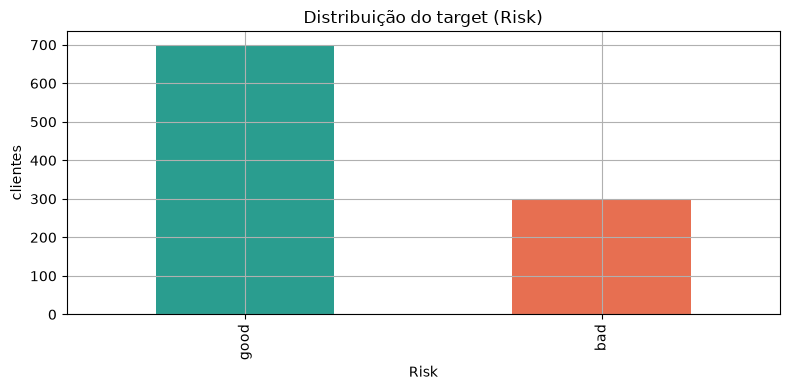

,n,%
Risk,,
good,700,70.0
bad,300,30.0


In [6]:
counts = df['Risk'].value_counts()
pct = df['Risk'].value_counts(normalize=True).mul(100).round(1)
summary = pd.concat([counts, pct], axis=1)
summary.columns = ['n', '%']
ax = counts.plot(kind='bar', color=['#2a9d8f', '#e76f51'])
ax.set_title('Distribuição do target (Risk)')
ax.set_ylabel('clientes'); plt.tight_layout(); plt.show()
summary

Dataset **desbalanceado**: ~70% `good` / ~30% `bad`. Isso justifica olhar métricas além da acurácia (ROC-AUC, F1 da classe `bad`) — como feito no baseline.

## 3. Features numéricas

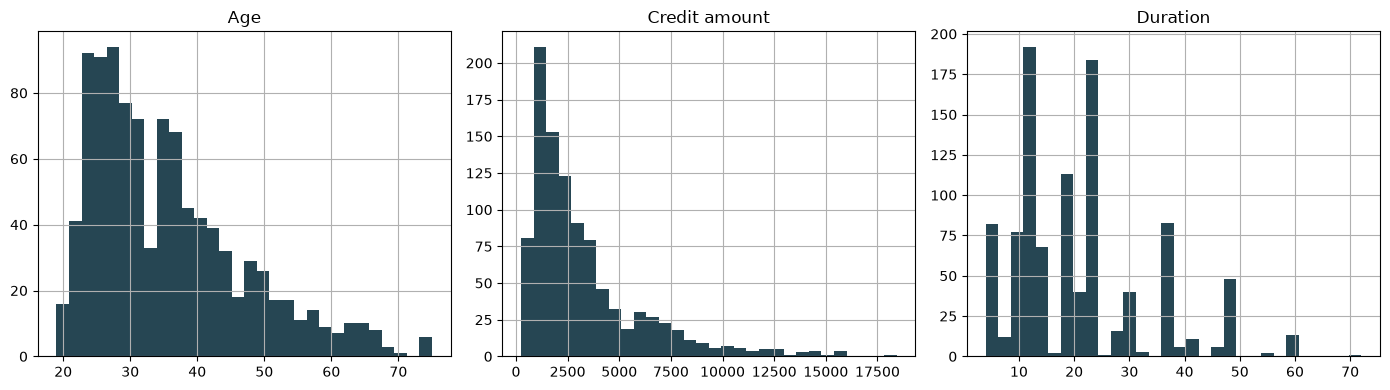

In [7]:
num = ['Age', 'Credit amount', 'Duration']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num):
    ax.hist(df[col], bins=30, color='#264653')
    ax.set_title(col)
plt.tight_layout(); plt.show()

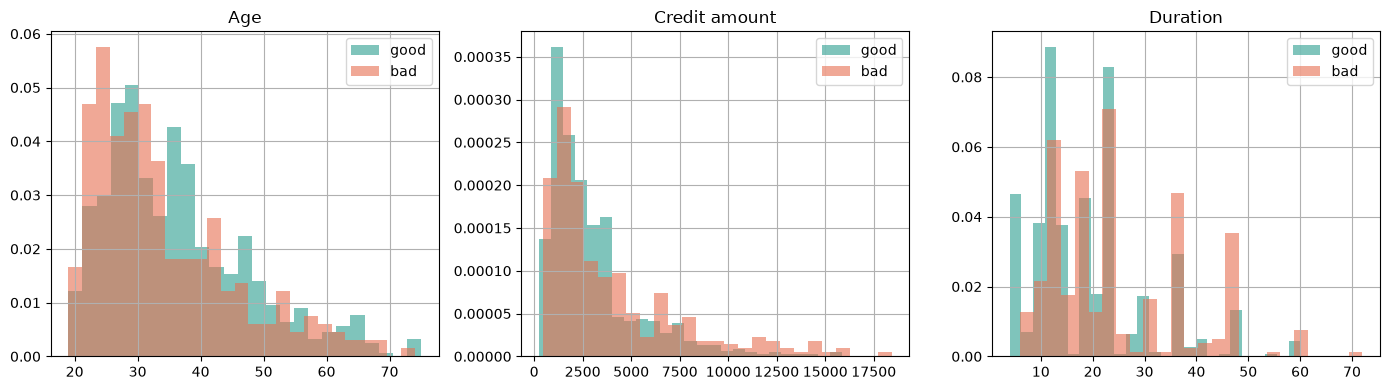

In [8]:
# Distribuição das numéricas por classe de risco
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num):
    for risk, color in [('good', '#2a9d8f'), ('bad', '#e76f51')]:
        ax.hist(df.loc[df['Risk'] == risk, col], bins=25, alpha=0.6,
                label=risk, color=color, density=True)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

In [9]:
# Médias por classe
df.groupby('Risk')[num].mean().round(1)

,Age,Credit amount,Duration
Risk,,,
bad,34.0,3938.1,24.9
good,36.2,2985.5,19.2


Leitura: clientes `bad` tendem a pedir **crédito maior** e **prazos mais longos**. `Age` separa menos as classes.

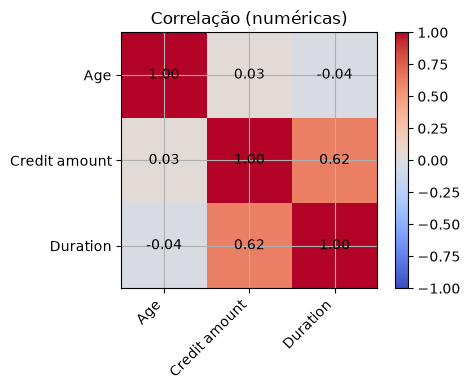

In [10]:
# Correlação entre numéricas
corr = df[num].corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha='right')
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for i in range(len(num)):
    for j in range(len(num)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im); ax.set_title('Correlação (numéricas)'); plt.tight_layout(); plt.show()

`Credit amount` e `Duration` são correlacionados (crédito maior → prazo maior).

## 4. Features categóricas e taxa de inadimplência

In [11]:
cat = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
def bad_rate(col):
    g = df.groupby(col)['Risk'].apply(lambda s: (s == 'bad').mean())
    n = df[col].value_counts()
    out = pd.concat([n, g.mul(100).round(1)], axis=1)
    out.columns = ['n', 'bad_rate_%']
    return out.sort_values('bad_rate_%', ascending=False)

for c in cat:
    print(f'\n=== {c} ===')
    print(bad_rate(c).to_string())


=== Sex ===
          n  bad_rate_%
Sex                    
female  310        35.2
male    690        27.7

=== Job ===
       n  bad_rate_%
Job                 
3    148        34.5
0     22        31.8
2    630        29.5
1    200        28.0

=== Housing ===
           n  bad_rate_%
Housing                 
free     108        40.7
rent     179        39.1
own      713        26.1

=== Saving accounts ===
                   n  bad_rate_%
Saving accounts                 
little           603        36.0
moderate         103        33.0
no_account       183        17.5
quite rich        63        17.5
rich              48        12.5

=== Checking account ===
                    n  bad_rate_%
Checking account                 
little            274        49.3
moderate          269        39.0
rich               63        22.2
no_account        394        11.7

=== Purpose ===
                       n  bad_rate_%
Purpose                             
vacation/others       12        4

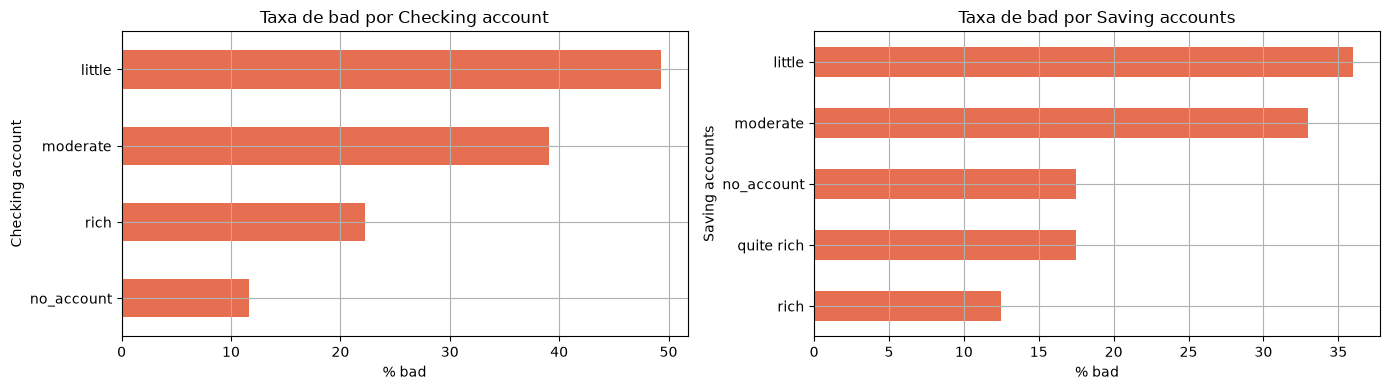

In [12]:
# Taxa de 'bad' por categoria (visual) para as variáveis mais informativas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Checking account', 'Saving accounts']):
    br = df.groupby(col)['Risk'].apply(lambda s: (s == 'bad').mean()).sort_values()
    br.mul(100).plot(kind='barh', ax=ax, color='#e76f51')
    ax.set_title(f'Taxa de bad por {col}'); ax.set_xlabel('% bad')
plt.tight_layout(); plt.show()

Contas com **pouco saldo / sem conta** concentram maior taxa de inadimplência — coerente com o domínio de crédito. Por isso `Checking account` foi uma das variáveis escolhidas para simular drift de recessão na Etapa 2.

## 5. Sinais de viés / PII (insumo para a Governança — Etapa 4)

`Sex` e `Age` são atributos sensíveis. Comparar a taxa de `bad` entre grupos ajuda a antecipar risco de **viés** na decisão de crédito.

In [13]:
print('Taxa de bad por Sexo:')
print(df.groupby('Sex')['Risk'].apply(lambda s: (s == 'bad').mean()).mul(100).round(1))

df['faixa_idade'] = pd.cut(df['Age'], bins=[17, 25, 35, 50, 100],
                           labels=['18-25', '26-35', '36-50', '50+'])
print('\nTaxa de bad por faixa de idade:')
print(df.groupby('faixa_idade', observed=True)['Risk']
        .apply(lambda s: (s == 'bad').mean()).mul(100).round(1))

Taxa de bad por Sexo:
Sex
female    35.2
male      27.7
Name: Risk, dtype: float64

Taxa de bad por faixa de idade:
faixa_idade
18-25    42.1
26-35    29.6
36-50    23.7
50+      27.4
Name: Risk, dtype: float64


Há diferença de taxa de `bad` entre sexos e faixas de idade. Isso **não** implica causalidade, mas é um alerta de *fairness*: usar esses atributos direto na decisão pode reproduzir viés — ponto a tratar no plano de governança/LGPD.

## 6. Prévia do Drift (Referência × Produção — Etapa 2)

Visualização direta da degradação injetada, se os CSVs da Etapa 2 já existem.

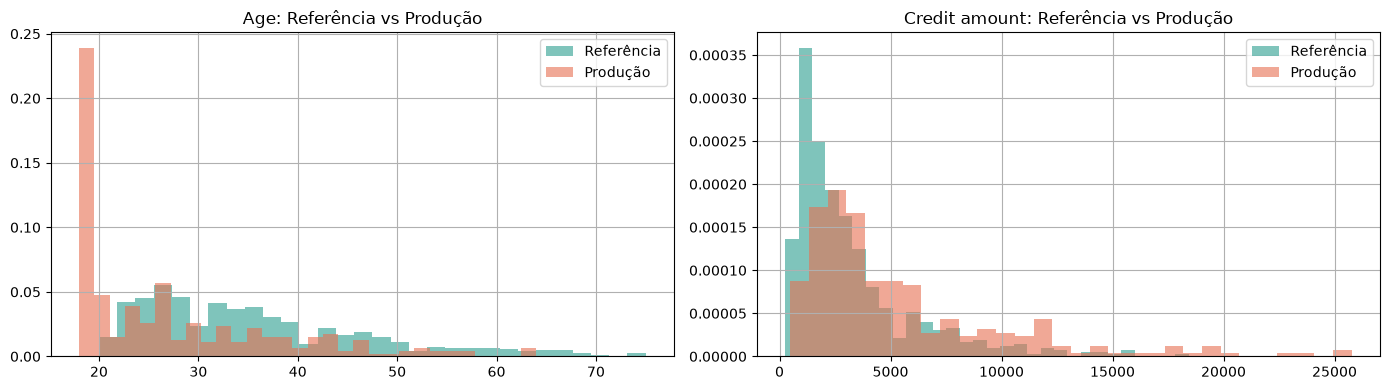

In [14]:
ref_p = ROOT / 'data' / 'reference' / 'reference.csv'
prod_p = ROOT / 'data' / 'production' / 'production.csv'
if ref_p.exists() and prod_p.exists():
    ref = pd.read_csv(ref_p); prod = pd.read_csv(prod_p)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, col in zip(axes, ['Age', 'Credit amount']):
        ax.hist(ref[col], bins=30, alpha=0.6, label='Referência', density=True, color='#2a9d8f')
        ax.hist(prod[col], bins=30, alpha=0.6, label='Produção', density=True, color='#e76f51')
        ax.set_title(f'{col}: Referência vs Produção'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('CSVs de Etapa 2 ausentes. Rode: python -m src.credit.run_etapa2')

O deslocamento das distribuições confirma visualmente o **Data Drift** medido por PSI/KS no relatório do Evidently (`reports/drift_report.html`).

### Conclusões
- Dataset pequeno (1.000) e desbalanceado (30% `bad`) → priorizar ROC-AUC/F1.
- `Credit amount`, `Duration` e o status das contas são os sinais mais fortes de risco.
- `Sex`/`Age` exigem atenção de *fairness* na governança.
- O drift injetado em `Age` e `Credit amount` é visível e mensurável — base da Etapa 2.